# Smartphone Addiction Prediction — Playground Series S6E8

**Approach**: EDA → correlation-aware missing value imputation → categorical encoding → 
three-model ensemble (CatBoost, XGBoost, LightGBM) with grid-searched blend weights.

**Public LB score**: 0.9654 ROC-AUC

## Highlights

- **Missing value strategy**: instead of filling numeric gaps with plain median/mean, 
  I first mapped out pairwise correlations between features (several pairs above 0.5, 
  one as high as 0.80) and used `IterativeImputer` to predict missing values from 
  related columns rather than ignoring that structure.
- **Careful train/test separation**: all imputation and encoding statistics 
  (mode, median, learned mappings) are fit on train only and applied to test — 
  no information leakage between the two sets.
- **Model ensemble**: trained CatBoost, XGBoost, and LightGBM separately, then found 
  the optimal blend weights via grid search over validation ROC-AUC rather than 
  simple equal-weight averaging.
- **Honest validation**: used a stratified train/validation split throughout, 
  so the reported metrics reflect genuine generalization rather than in-sample fit.

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
from sklearn.model_selection import StratifiedKFold

## Data Loading

In [2]:
train_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

In [3]:
train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


## EDA

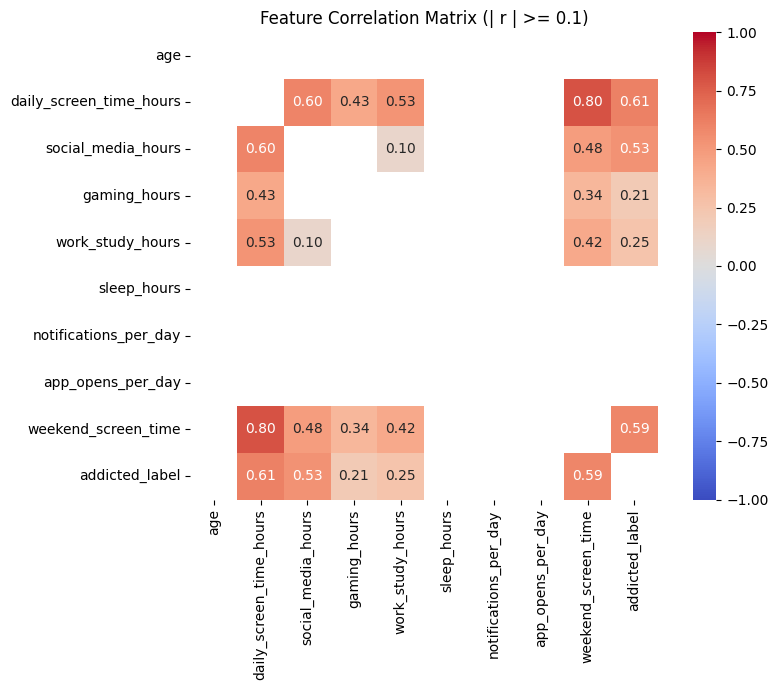

In [4]:
# Define features for correlation matrix
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                 'app_opens_per_day', 'weekend_screen_time']

all_cols = numeric_cols + ['addicted_label']
corr_matrix = train_data[all_cols].corr()

# Hide weak correlations (|r| < 0.1) and self-correlations on the diagonal
mask = np.abs(corr_matrix) < 0.1
np.fill_diagonal(mask.values, True) 

# Create the heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, center=0, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix (| r | >= 0.1)')
plt.tight_layout()
plt.show()

## Correlation Structure

Before choosing an imputation strategy, I looked at pairwise correlations across 
all numeric features (including the target) to understand how much structure 
was available to exploit.

**Strong (r ≥ 0.5)**
- `daily_screen_time_hours` ↔ `weekend_screen_time` — 0.800
- `daily_screen_time_hours` ↔ `addicted_label` — 0.611
- `social_media_hours` ↔ `daily_screen_time_hours` — 0.596
- `addicted_label` ↔ `weekend_screen_time` — 0.590
- `social_media_hours` ↔ `addicted_label` — 0.532
- `daily_screen_time_hours` ↔ `work_study_hours` — 0.526

**Moderate (0.3 ≤ r < 0.5)**
- `social_media_hours` ↔ `weekend_screen_time` — 0.478
- `gaming_hours` ↔ `daily_screen_time_hours` — 0.429
- `work_study_hours` ↔ `weekend_screen_time` — 0.418
- `gaming_hours` ↔ `weekend_screen_time` — 0.342

**Weak (r < 0.3)**
- `gaming_hours` ↔ `addicted_label` — 0.205
- `social_media_hours` ↔ `work_study_hours` — 0.101

**Takeaway**: screen-time-related features (`daily_screen_time_hours`, 
`weekend_screen_time`, `social_media_hours`) form a tightly correlated cluster 
and are also the strongest predictors of `addicted_label`. This structure is 
exactly what `IterativeImputer` can exploit — filling a missing value in one 
of these columns using the others is far more informative than a plain median.

In [5]:
def check_nonlinear_signal(df, feature, target, n_bins=10):
    valid = df[[feature, target]].dropna()
    bins = pd.qcut(valid[feature], q=n_bins, duplicates='drop')
    decile_means = valid.groupby(bins, observed=True)[target].mean()
    print(f"\nDispersion between groups: {(decile_means.max() - decile_means.min()) * 100:.2f}")

    # Plotting
    plt.figure(figsize=(6, 3))
    sns.lineplot(x=decile_means.index.astype(str), y=decile_means.values, marker='o', color='#2b5c8f')
    plt.title(f'Nonlinear Signal: {feature} vs {target}', fontsize=12, fontweight='bold')
    plt.xlabel(f'{feature} Intervals')
    plt.ylabel(f'Mean of {target}')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(decile_means.min() - 0.02, decile_means.max() + 0.02)
    plt.tight_layout()
    plt.show()


Dispersion between groups: 7.39


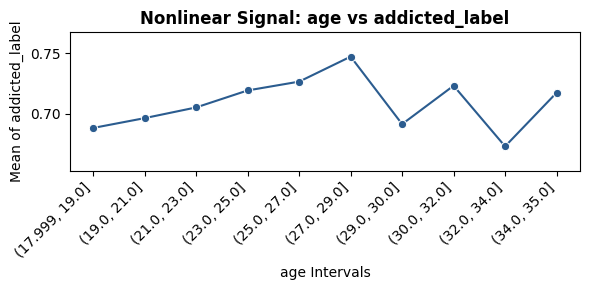


Dispersion between groups: 6.30


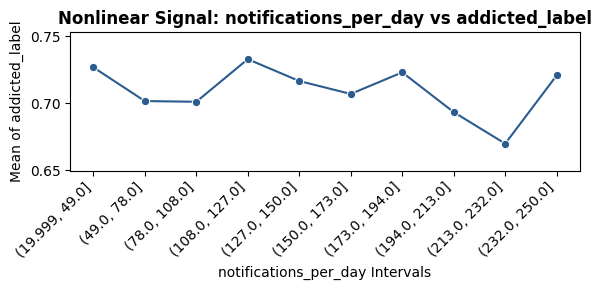


Dispersion between groups: 12.52


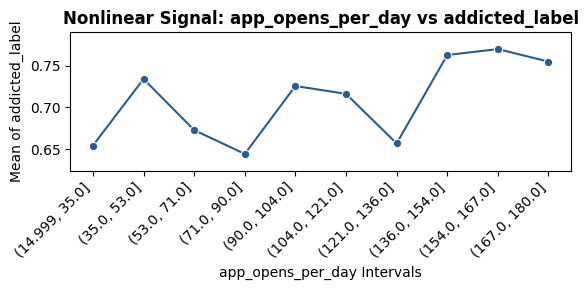


Dispersion between groups: 7.82


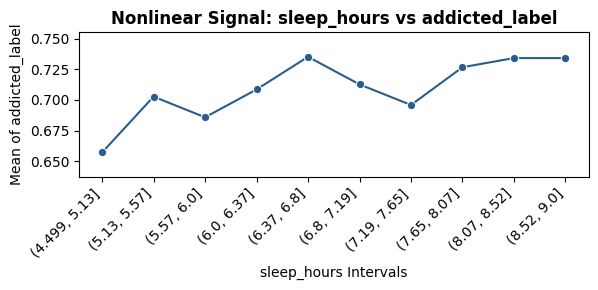

In [6]:
check_nonlinear_signal(train_data, 'age', 'addicted_label')
check_nonlinear_signal(train_data, 'notifications_per_day', 'addicted_label')
check_nonlinear_signal(train_data, 'app_opens_per_day', 'addicted_label')
check_nonlinear_signal(train_data, 'sleep_hours', 'addicted_label')

## Filling Missing Values

In [7]:
# Create missing_count
cols_with_possible_missing = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                                'work_study_hours', 'sleep_hours', 'notifications_per_day',
                                'app_opens_per_day', 'weekend_screen_time', 
                                'gender', 'stress_level', 'academic_work_impact']

train_data['missing_count'] = train_data[cols_with_possible_missing].isna().sum(axis=1)
test_data['missing_count'] = test_data[cols_with_possible_missing].isna().sum(axis=1)

### 1. Numerical columns

In [8]:
train_data.isna().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
missing_count                   0
dtype: int64

In [9]:
test_data.isna().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
missing_count                  0
dtype: int64

In [10]:
# Fill missing values by medians columns with weak correlations

median_cols = ['age', 'notifications_per_day', 'app_opens_per_day', 'sleep_hours']

for col in median_cols:
    train_data[col]= train_data[col].fillna(train_data[col].median())
    test_data[col]= test_data[col].fillna(train_data[col].median())

In [11]:
# Impute missing values using IterativeImputer

# Columns that have correlations with each other
corr_numeric_cols = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours', 'work_study_hours', 'gaming_hours']

# Create & fit the imputer
imputer = IterativeImputer(random_state=42)
imputer.fit(train_data[corr_numeric_cols])

# Transform train & test data
train_data[corr_numeric_cols] = imputer.transform(train_data[corr_numeric_cols])
test_data[corr_numeric_cols] = imputer.transform(test_data[corr_numeric_cols])

train_data[corr_numeric_cols + ['addicted_label']].corr()

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,daily_screen_time_hours,weekend_screen_time,social_media_hours,work_study_hours,gaming_hours,addicted_label
daily_screen_time_hours,1.000000,0.832932,0.631564,0.549339,0.462395,0.603257
weekend_screen_time,0.832932,1.000000,0.522925,0.442499,0.379892,0.584789
social_media_hours,0.631564,0.522925,1.000000,0.109301,0.112970,0.528233
work_study_hours,0.549339,0.442499,0.109301,1.000000,0.053408,0.257608
gaming_hours,0.462395,0.379892,0.112970,0.053408,1.000000,0.223589
addicted_label,0.603257,0.584789,0.528233,0.257608,0.223589,1.000000


In [12]:
# Make new columns 

# Create social_media_share
train_data['social_media_share'] = train_data['social_media_hours'] / train_data['daily_screen_time_hours']
test_data['social_media_share'] = test_data['social_media_hours'] / test_data['daily_screen_time_hours']

train_data['social_media_share'] = train_data['social_media_share'].replace([np.inf, -np.inf], 0)
test_data['social_media_share'] = test_data['social_media_share'].replace([np.inf, -np.inf], 0)

# Create gaming_share
train_data['gaming_share'] = train_data['gaming_hours'] / train_data['daily_screen_time_hours']
test_data['gaming_share'] = test_data['gaming_hours'] / test_data['daily_screen_time_hours']

train_data['gaming_share'] = train_data['gaming_share'].replace([np.inf, -np.inf], 0)
test_data['gaming_share'] = test_data['gaming_share'].replace([np.inf, -np.inf], 0)

# Create weekend_and_weekday_diff
train_data['weekend_and_weekday_diff'] = train_data['weekend_screen_time'] - train_data['daily_screen_time_hours']
test_data['weekend_and_weekday_diff'] = test_data['weekend_screen_time'] - test_data['daily_screen_time_hours']

# Create leisure_to_study_ratio
train_data['leisure_to_study_ratio'] = (train_data['social_media_hours'] + train_data['gaming_hours'])/ train_data['work_study_hours']
test_data['leisure_to_study_ratio'] = (test_data['social_media_hours'] + test_data['gaming_hours'])/ test_data['work_study_hours']

train_data['leisure_to_study_ratio'] = train_data['leisure_to_study_ratio'].replace([np.inf, -np.inf], 0)
test_data['leisure_to_study_ratio'] = test_data['leisure_to_study_ratio'].replace([np.inf, -np.inf], 0)

# Create waking_hours                                                                                  
train_data['waking_hours'] = 24.0 - train_data['sleep_hours']  
test_data['waking_hours'] = 24.0 - test_data['sleep_hours'] 

# Create daily_screen_time_share
train_data['daily_screen_time_share'] = train_data['daily_screen_time_hours'] / train_data['waking_hours']
test_data['daily_screen_time_share'] = test_data['daily_screen_time_hours'] / test_data['waking_hours']

train_data['daily_screen_time_share'] = train_data['daily_screen_time_share'].replace([np.inf, -np.inf], 0)
test_data['daily_screen_time_share'] = test_data['daily_screen_time_share'].replace([np.inf, -np.inf], 0)

# Create mysterios_screen_time
train_data['mysterios_screen_time'] = train_data['daily_screen_time_hours'] - (train_data['social_media_hours'] + train_data['gaming_hours'] + train_data['work_study_hours'])
test_data['mysterios_screen_time'] = test_data['daily_screen_time_hours'] - (test_data['social_media_hours'] + test_data['gaming_hours'] + test_data['work_study_hours'])

In [13]:
# Create age_bin
_, bin_edges_age = pd.qcut(train_data['age'], q=10, retbins=True, duplicates='drop')

train_data['age_bin'] = pd.cut(train_data['age'], bins=bin_edges_age, labels=False, include_lowest=True)
test_data['age_bin'] = pd.cut(test_data['age'], bins=bin_edges_age, labels=False, include_lowest=True)

# Create app_opens_per_day_bin
_, bin_edges_app_opens = pd.qcut(train_data['app_opens_per_day'], q=10, retbins=True, duplicates='drop')

train_data['app_opens_per_day_bin'] = pd.cut(train_data['app_opens_per_day'], bins=bin_edges_app_opens, labels=False, include_lowest=True)
test_data['app_opens_per_day_bin'] = pd.cut(test_data['app_opens_per_day'], bins=bin_edges_app_opens, labels=False, include_lowest=True)

# Create app_opens_per_day_bin
_, bin_edges_sleep = pd.qcut(train_data['sleep_hours'], q=10, retbins=True, duplicates='drop')

train_data['sleep_hours_bin'] = pd.cut(train_data['sleep_hours'], bins=bin_edges_sleep, labels=False, include_lowest=True)
test_data['sleep_hours_bin'] = pd.cut(test_data['sleep_hours'], bins=bin_edges_sleep, labels=False, include_lowest=True)

### 2. Categorical columns

In [14]:
categorical_cols = ['stress_level', 'gender', 'academic_work_impact']

# Fill missing values using mode
for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

In [15]:
train_data.isna().sum()

id                          0
age                         0
daily_screen_time_hours     0
social_media_hours          0
gaming_hours                0
work_study_hours            0
sleep_hours                 0
notifications_per_day       0
app_opens_per_day           0
weekend_screen_time         0
gender                      0
stress_level                0
academic_work_impact        0
addicted_label              0
missing_count               0
social_media_share          0
gaming_share                0
weekend_and_weekday_diff    0
leisure_to_study_ratio      0
waking_hours                0
daily_screen_time_share     0
mysterios_screen_time       0
age_bin                     0
app_opens_per_day_bin       0
sleep_hours_bin             0
dtype: int64

In [16]:
test_data.isna().sum()

id                          0
age                         0
daily_screen_time_hours     0
social_media_hours          0
gaming_hours                0
work_study_hours            0
sleep_hours                 0
notifications_per_day       0
app_opens_per_day           0
weekend_screen_time         0
gender                      0
stress_level                0
academic_work_impact        0
missing_count               0
social_media_share          0
gaming_share                0
weekend_and_weekday_diff    0
leisure_to_study_ratio      0
waking_hours                0
daily_screen_time_share     0
mysterios_screen_time       0
age_bin                     0
app_opens_per_day_bin       0
sleep_hours_bin             0
dtype: int64

## Encoding

In [17]:
# One-Hot encoding ('gender' column)
train_data = pd.get_dummies(train_data, columns=['gender'], drop_first=True) 
test_data = pd.get_dummies(test_data, columns=['gender'], drop_first=True)

In [18]:
# Ordinal encoding ('stress_level' column)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
train_data['stress_level_encoded'] = train_data['stress_level'].map(stress_map)
test_data['stress_level_encoded'] = test_data['stress_level'].map(stress_map)

In [19]:
# Ordinal encoding ('academic_work_impact' column)
academic_work_impact_map = {'No': 0, 'Yes': 1}
train_data['academic_work_impact_encoded'] = train_data['academic_work_impact'].map(academic_work_impact_map)
test_data['academic_work_impact_encoded'] = test_data['academic_work_impact'].map(academic_work_impact_map)

In [20]:
# Drop useless columns
train_data = train_data.drop(columns=['stress_level', 'academic_work_impact'], axis=1)
test_data = test_data.drop(columns=['stress_level', 'academic_work_impact'], axis=1)

## Train-Test Splitting

In [21]:
X = train_data.drop(columns=['addicted_label', 'id'])
y = train_data['addicted_label']
X_test = test_data.drop(columns=['id'])

## StratifiedKFold

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_cat = np.zeros(len(X))
oof_preds_lgbm = np.zeros(len(X))
oof_preds_xgb = np.zeros(len(X))

test_preds_cat = np.zeros(len(X_test))
test_preds_lgbm = np.zeros(len(X_test))
test_preds_xgb = np.zeros(len(X_test))

fold_scores_cat = []
fold_scores_lgbm = []
fold_scores_xgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_cat = CatBoostClassifier(iterations=500, random_state=42, verbose=0)
    model_cat.fit(X_train_fold, y_train_fold)
    model_lgbm = LGBMClassifier(n_estimators=500, random_state=42)
    model_lgbm.fit(X_train_fold, y_train_fold)
    model_xgb = XGBClassifier(n_estimators=500, random_state=42)
    model_xgb.fit(X_train_fold, y_train_fold)

    val_preds_cat = model_cat.predict_proba(X_val_fold)[:, 1]
    oof_preds_cat[val_idx] = val_preds_cat
    fold_score_cat = roc_auc_score(y_val_fold, val_preds_cat)
    fold_scores_cat.append(fold_score_cat)

    val_preds_lgbm = model_lgbm.predict_proba(X_val_fold)[:, 1]
    oof_preds_lgbm[val_idx] = val_preds_lgbm
    fold_score_lgbm = roc_auc_score(y_val_fold, val_preds_lgbm)
    fold_scores_lgbm.append(fold_score_lgbm)

    val_preds_xgb = model_xgb.predict_proba(X_val_fold)[:, 1]
    oof_preds_xgb[val_idx] = val_preds_xgb
    fold_score_xgb = roc_auc_score(y_val_fold, val_preds_xgb)
    fold_scores_xgb.append(fold_score_xgb)

    print(f"Fold {fold}: CatBoost={fold_score_cat:.5f}, LGBM={fold_score_lgbm:.5f}, XGBoost={fold_score_xgb:.5f}")

    test_pred_cat = model_cat.predict_proba(X_test)[:, 1]
    test_preds_cat += test_pred_cat / 5

    test_pred_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
    test_preds_lgbm += test_pred_lgbm / 5

    test_pred_xgb = model_xgb.predict_proba(X_test)[:, 1]
    test_preds_xgb += test_pred_xgb / 5

print(f"\nMean CatBoost ROC-AUC across 5 folds: {np.mean(fold_scores_cat):.5f} (std: {np.std(fold_scores_cat):.5f})")
print("OOF ROC-AUC (CatBoost):", roc_auc_score(y, oof_preds_cat))

print(f"\nMean LGBM ROC-AUC across 5 folds: {np.mean(fold_scores_lgbm):.5f} (std: {np.std(fold_scores_lgbm):.5f})")
print("OOF ROC-AUC (LGBM):", roc_auc_score(y, oof_preds_lgbm))

print(f"\nMean XGBoost ROC-AUC across 5 folds: {np.mean(fold_scores_xgb):.5f} (std: {np.std(fold_scores_xgb):.5f})")
print("OOF ROC-AUC (XGBoost):", roc_auc_score(y, oof_preds_xgb))

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3771
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
Fold 0: CatBoost=0.96162, LGBM=0.95992, XGBoost=0.96180
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3769
[LightGBM] [Info] Number of data points in the train

## Final Models

In [23]:
# Find the best weights for ensemble & ROC-AUC score
best_score = 0
best_weights = None

for w1 in np.arange(0, 1.05, 0.05):
    for w2 in np.arange(0, 1.05 - w1, 0.05):
        w3 = 1 - w1 - w2
        combined = w1 * oof_preds_cat + w2 * oof_preds_xgb + w3 * oof_preds_lgbm
        score = roc_auc_score(y, combined)
        if score > best_score:
            best_score = score
            best_weights = (w1, w2, w3)

print(f"\nThe best weights (cat, xgb, lgbm): {best_weights}")
print(f"The best ensemble ROC-AUC: {best_score:.4f}")


The best weights (cat, xgb, lgbm): (np.float64(0.4), np.float64(0.5), np.float64(0.09999999999999998))
The best ensemble ROC-AUC: 0.9637


In [24]:
w1, w2, w3 = best_weights
final_proba = w1 * test_preds_cat + w2 * test_preds_xgb + w3 * test_preds_lgbm

## Submission 

In [25]:
submission = pd.DataFrame({
    'id': test_data['id'],
    'addicted_label': final_proba 
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

       id  addicted_label
0  691369        0.999522
1  691370        0.930571
2  691371        0.964847
3  691372        0.989314
4  691373        0.998717
